In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/cleaned_cricket_data.csv')

# Display the first few rows and info to understand the data
print("DataFrame Info:")
df.info()
print("\nFirst 5 rows of the DataFrame:")
display(df.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Match_ID            4998 non-null   int64  
 1   Innings             4998 non-null   int64  
 2   Batting_Team        4998 non-null   object 
 3   Bowling_Team        4998 non-null   object 
 4   Venue               4467 non-null   object 
 5   Match_Format        4998 non-null   object 
 6   Batsman_Name        4998 non-null   object 
 7   Bowler_Name         4998 non-null   object 
 8   Runs_Scored         4998 non-null   int64  
 9   Balls_Faced         4998 non-null   int64  
 10  Fours               4998 non-null   int64  
 11  Sixes               4998 non-null   int64  
 12  Total_Boundaries    4998 non-null   int64  
 13  Strike_Rate_Calc    4967 non-null   float64
 14  Wickets_Taken       4998 non-null   int64  
 15  Overs_Numeric       1699 non-null   flo

,Match_ID,Innings,Batting_Team,Bowling_Team,Venue,Match_Format,Batsman_Name,Bowler_Name,Runs_Scored,Balls_Faced,...,Overs_Numeric,Economy_Rate,Dismissal_Type,Player_Role,Match_Date_Clean,Match_Month,Match_Year,Batting_StrikeRate,Bowling_Economy,Match_Result
0,78001,2,India,West Indies,Melbourne,ODI,Williamson,Afridi,160,16,...,5.912402,15.90,Caught,Bowler,2020-01-01,2020-01,2020.0,1000.000000,27.061760,Incomplete
1,65307,1,England,New Zealand,Auckland,ODI,Kohli,Southee,32,33,...,5.912402,9.13,Caught,Batsman,NaN,NaN,NaN,96.969697,5.412352,Loss
2,26732,2,Australia,West Indies,Auckland,ODI,Kohli,Joseph,43,109,...,5.912402,6.09,Run Out,Batsman,NaN,NaN,NaN,39.449541,7.272848,Incomplete
3,18742,1,Afghanistan,New Zealand,Mumbai,T20,Williamson,Woakes,167,74,...,NaN,NaN,LBW,Batsman,NaN,NaN,NaN,225.675676,NaN,Incomplete
4,10028,1,Australia,South Africa,Kolkata,ODI,Smith,Malinga,129,136,...,NaN,NaN,LBW,All-Rounder,NaN,NaN,NaN,94.852941,NaN,Incomplete


### 1. Line chart → Runs over match dates

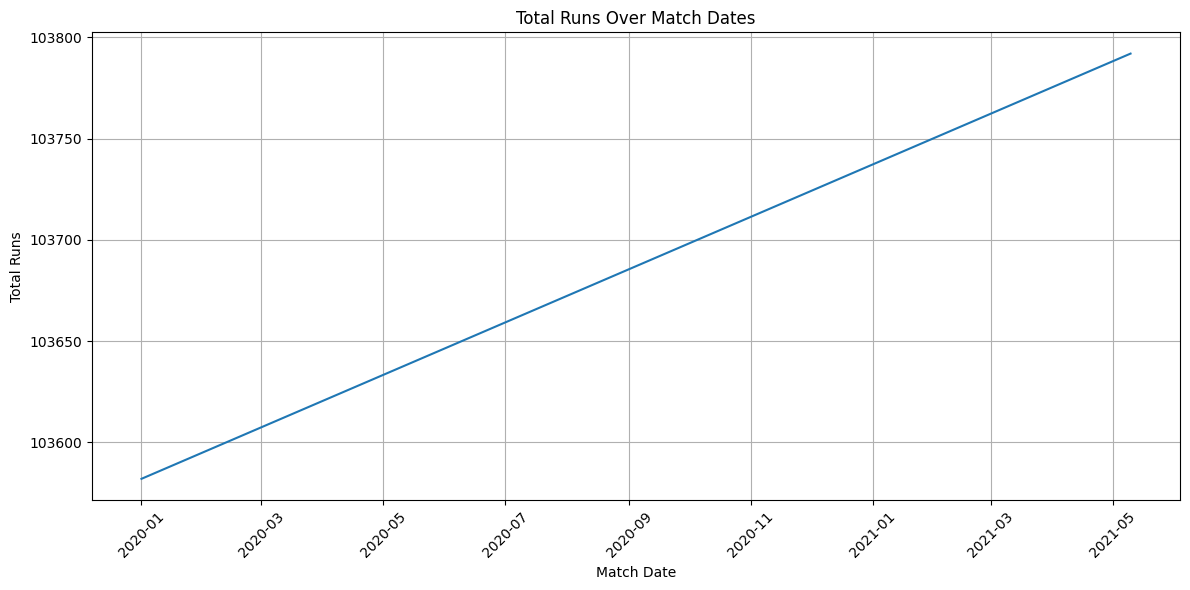

In [3]:
# Convert 'Match_Date_Clean' to datetime objects
df['Match_Date_Clean'] = pd.to_datetime(df['Match_Date_Clean'])

# Group by 'Match_Date_Clean' and sum the 'Runs_Scored'
daily_runs = df.groupby('Match_Date_Clean')['Runs_Scored'].sum().reset_index()

# Plot the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Match_Date_Clean', y='Runs_Scored', data=daily_runs)
plt.title('Total Runs Over Match Dates')
plt.xlabel('Match Date')
plt.ylabel('Total Runs')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Bar chart → Top 10 batsmen by total runs

/tmp/ipykernel_8465/2488806803.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Runs_Scored', y='Batsman_Name', data=top_10_batsmen, palette='viridis')


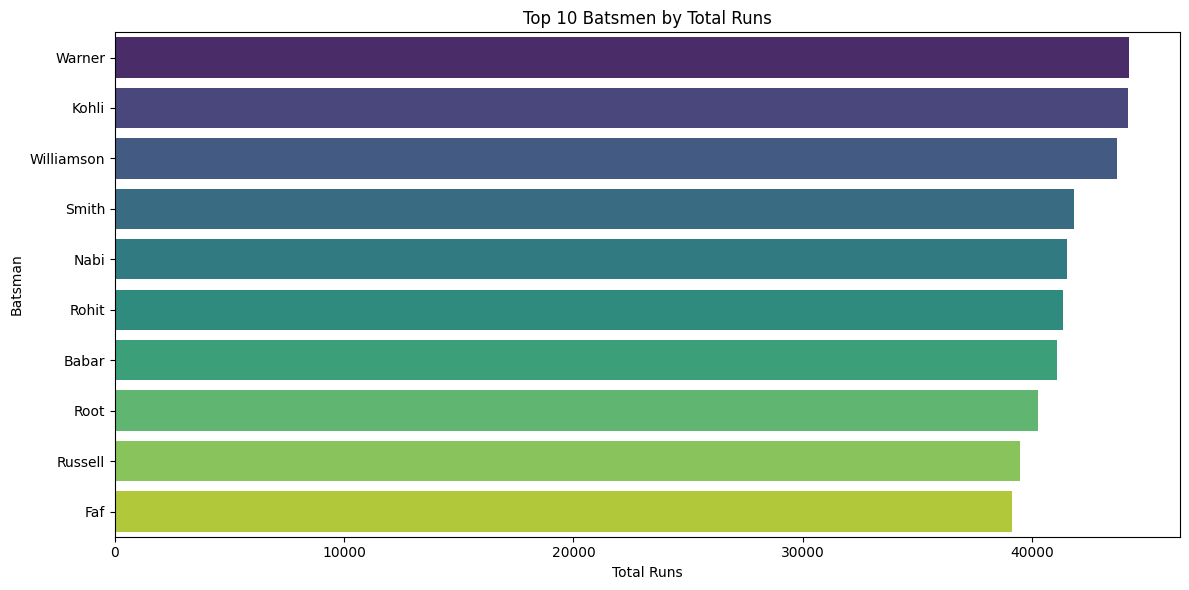

In [5]:
# Group by 'Batsman_Name' and sum 'Runs_Scored', then get the top 10
top_10_batsmen = df.groupby('Batsman_Name')['Runs_Scored'].sum().nlargest(10).reset_index()

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Runs_Scored', y='Batsman_Name', data=top_10_batsmen, palette='viridis')
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

### 3. Histogram → Strike Rate distribution

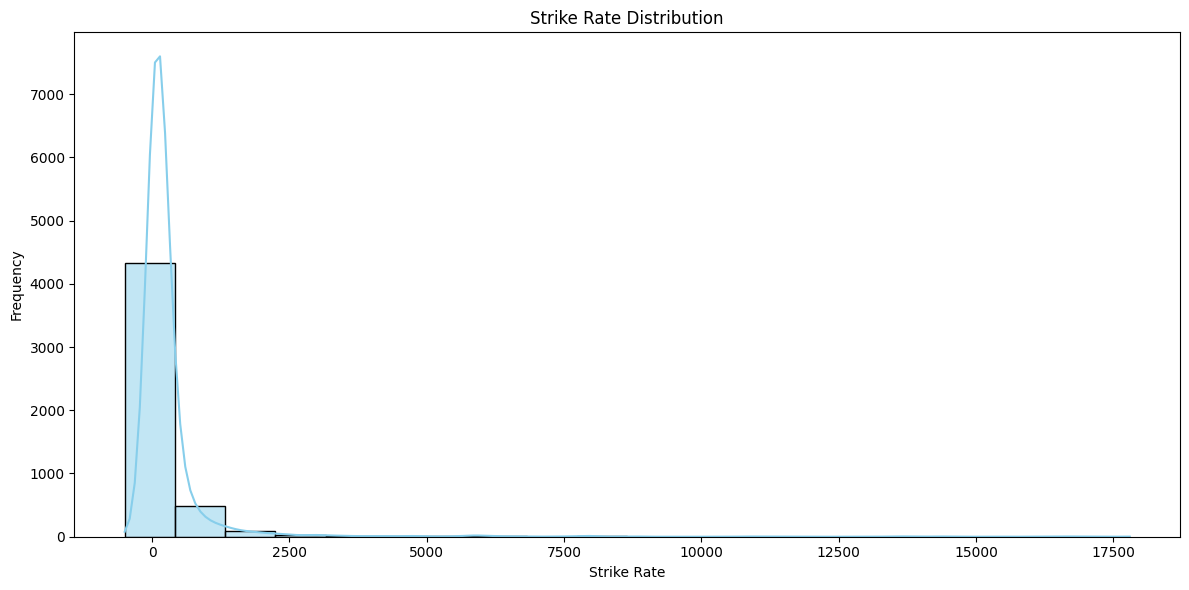

In [7]:
# Calculate 'Strike Rate' (Runs_Scored / Balls_Faced * 100)
# Handle cases where 'Balls_Faced' might be zero to avoid division by zero errors
df['Strike Rate'] = df.apply(lambda row: (row['Runs_Scored'] / row['Balls_Faced']) * 100 if row['Balls_Faced'] > 0 else 0, axis=1)

# Plot the histogram of 'Strike Rate'
plt.figure(figsize=(12, 6))
sns.histplot(df['Strike Rate'], bins=20, kde=True, color='skyblue')
plt.title('Strike Rate Distribution')
plt.xlabel('Strike Rate')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 4. Pie chart → Dismissal Type %

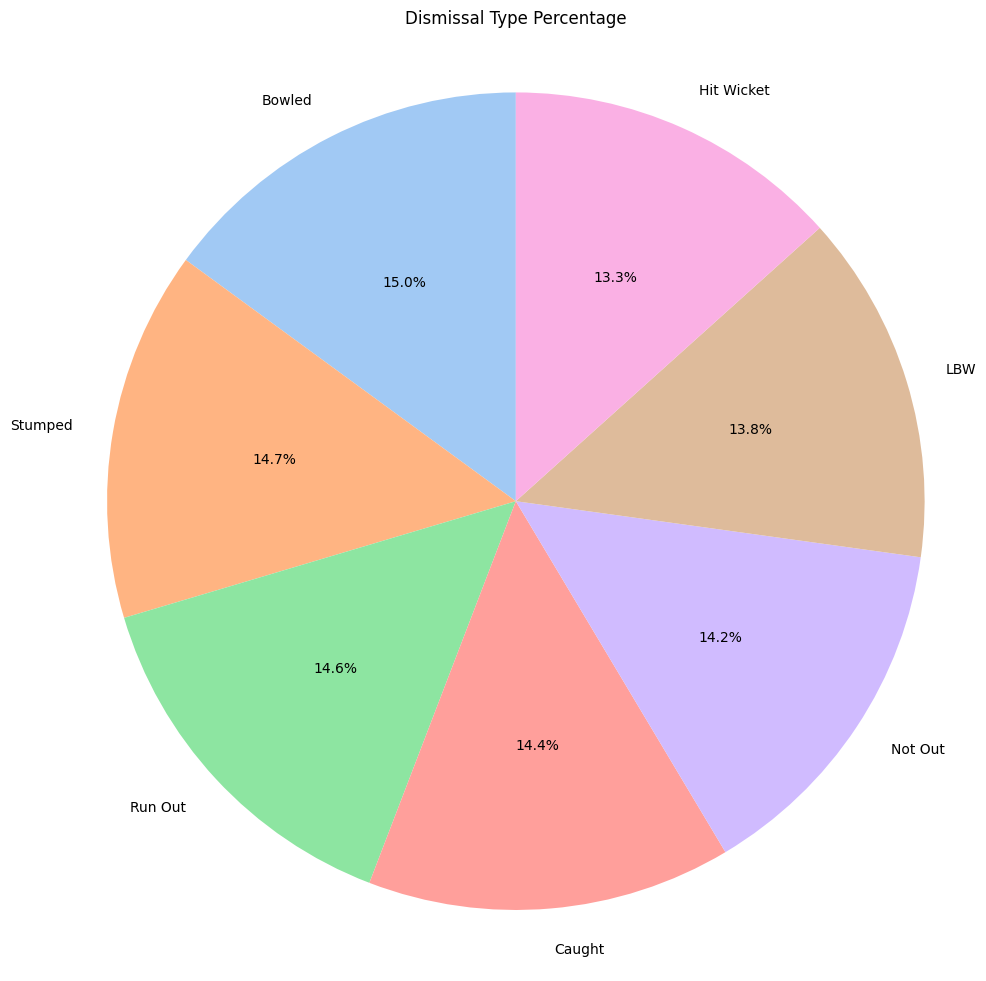

In [9]:
# Filter out rows where 'Dismissal_Type' is NaN or 'not out' for meaningful dismissal types
dismissal_types = df[df['Dismissal_Type'].notna() & (df['Dismissal_Type'] != 'not out')]['Dismissal_Type'].value_counts()

# Plot the pie chart
plt.figure(figsize=(10, 10))
plt.pie(dismissal_types, labels=dismissal_types.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Dismissal Type Percentage')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### 5. Scatter plot → Runs vs Balls Faced

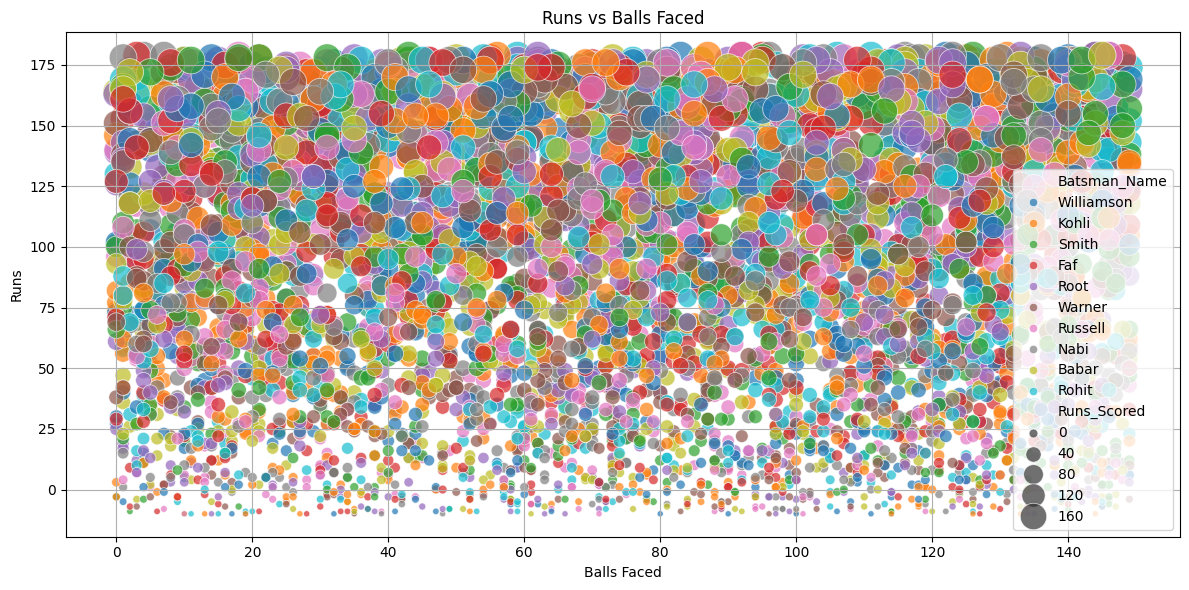

In [11]:
# Plot the scatter plot of 'Runs_Scored' vs 'Balls_Faced'
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Balls_Faced', y='Runs_Scored', data=df, hue='Batsman_Name', size='Runs_Scored', sizes=(20, 400), alpha=0.7)
plt.title('Runs vs Balls Faced')
plt.xlabel('Balls Faced')
plt.ylabel('Runs')
plt.grid(True)
plt.tight_layout()
plt.show()